Input A:  2
Input x0:  3
Input sig:  4
Input z0:  4
Input lower bound:  5
Input upper bound:  1


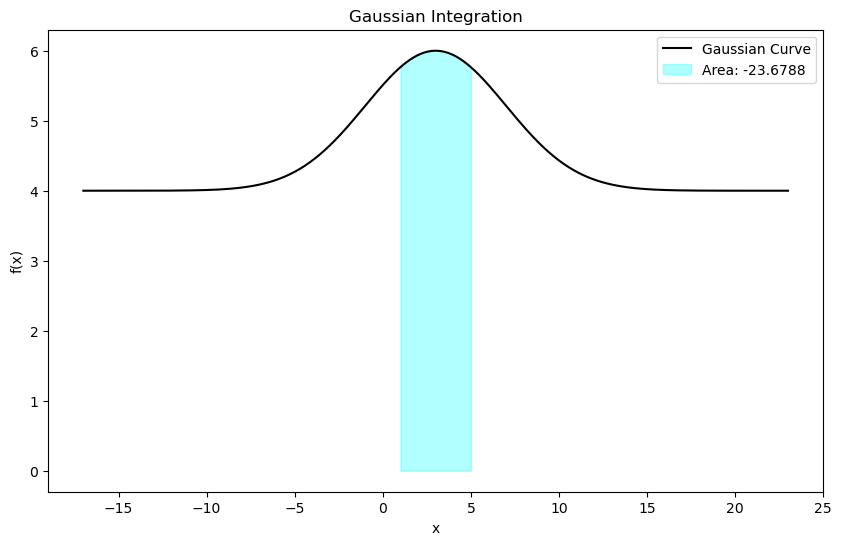

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

def int_tot_A(x, A, x0, sig, z0):
    return A*np.exp((-(x-x0)**2) / (2*sig**2)) + z0

A = float(input("Input A: "))
x0 = float(input("Input x0: "))
sig = float(input("Input sig: "))
z0 = float(input("Input z0: "))
a = float(input("Input lower bound: "))
b = float(input("Input upper bound: "))

# Calculate
area, error = integrate.quad(int_tot_A, a, b, args=(A, x0, sig, z0))

# Plotting range:
# To ensure that the user's input values are in the x-range it is useful to include, for example, 5 std "to the left and to the right".
# We can do the same to ensure that the input lower and upper bounds are also included
x_start = min(x0 - 5*sig, a - sig)  # !!! Important to use min() and max() to only create one value, not a tuple.
x_end = max(x0 + 5*sig, b + sig)
x_vals = np.linspace(x_start, x_end, 1000)
y_vals = int_tot_A(x_vals, A, x0, sig, z0)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'k-', label='Gaussian Curve')

# Shading integration area 
x_fill = np.linspace(a, b, 100)
y_fill = int_tot_A(x_fill, A, x0, sig, z0)
plt.fill_between(x_fill, y_fill, color='cyan', alpha=0.3, label=f"Area: {area:.4f}")

plt.title(f"Gaussian Integration")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()
